
Técnicas de Inteligencia Artificial


# Redes de neuronas para la resolución de un problema de clasificación



## Descripción del problema

El problema específico que queremos resolver es **predecir**, a partir de datos diarios, si el precio del oro cerrará en positivo (1) o en negativo (0). Para hacerlo utilizaremos una red de neuronas. Concretamente utilizaremos el algoritmo backpropagation y conoceremos su funcionamiento.


## Descripción de los datos

- **Date** = día en que se registró la información
- **Open** = precio de apertura del día (USD)
- **High** = precio máximo del día (USD)
- **Low** = precio mínimo del día (USD)
- **Close** = precio de cierre del día (USD)
- **WAP** = precio medio ponderado (USD)
- **No. of Shares** = número de acciones negociadas en el día
- **No. of Trades** = número de operaciones realizadas en el día
- **Total Turnover** = volumen total de intercambios
- **Deliverable Quantity** = número total de acciones marcadas para entrega en un día
- **% Deli. Qty to Traded Qty** = relación entre el % de cantidad entregable y la cantidad negociada
- **% Spread H-L** = diferencia entre los valores máximo y mínimo del día (USD)
- **% Spread C-O** = diferencia en USD entre los valores de cierre y apertura del día (USD)

### Paso 1. Importamos las librerías y cargamos el dataset

In [1]:
# Importamos las librerías necesarias
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# Leemos el dataset y vemos el número de variables que tiene
data = pd.read_csv('gld_price_data.csv', sep=',')
data.head(20)

,Date,Open,High,Low,Close,WAP,No. of Shares,No. of Trades,Total Turnover,Deliverable Quantity,% Deli. Qty to Traded Qty,Spread H-L,Spread C-O
0,2017-02-06,0.79,0.79,0.76,0.76,0.79,7430.0,7.0,5848.0,7430.0,100.0,0.03,-0.03
1,2017-02-03,0.79,0.79,0.79,0.79,0.79,310.0,4.0,244.0,310.0,100.0,0.00,0.00
2,2017-02-02,0.83,0.83,0.83,0.83,0.83,75.0,1.0,62.0,75.0,100.0,0.00,0.00
3,2017-01-31,0.87,0.87,0.87,0.87,0.87,1050.0,2.0,913.0,1050.0,100.0,0.00,0.00
4,2017-01-25,0.91,0.91,0.91,0.91,0.91,400.0,1.0,364.0,400.0,100.0,0.00,0.00
5,2017-01-24,0.91,0.91,0.90,0.91,0.91,3632.0,6.0,3303.0,3632.0,100.0,0.01,0.00
6,2017-01-23,0.91,0.91,0.91,0.91,0.91,55.0,1.0,50.0,55.0,100.0,0.00,0.00
7,2017-01-20,0.93,0.93,0.92,0.92,0.92,74.0,2.0,68.0,74.0,100.0,0.01,-0.01
8,2017-01-19,0.89,0.89,0.89,0.89,0.88,77.0,2.0,68.0,77.0,100.0,0.00,0.00
9,2017-01-18,0.88,0.88,0.85,0.85,0.87,84.0,2.0,73.0,84.0,100.0,0.03,-0.03


### Paso 2: Hacemos el análisis descriptivo de los datos

In [3]:
# Generamos estadísticas descriptivas  de los datos
data.describe()

,Open,High,Low,Close,WAP,No. of Shares,No. of Trades,Total Turnover,Deliverable Quantity,% Deli. Qty to Traded Qty,Spread H-L,Spread C-O
count,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1660.000000,1.660000e+03,1660.000000,1660.000000,1660.000000,1660.000000
mean,11.834367,12.174048,11.221578,11.673934,11.688802,101330.338554,122.983735,1.664520e+06,75754.484337,88.678651,0.952470,-0.160434
std,17.169590,17.704607,16.143363,16.837100,16.920058,140560.465729,138.844766,2.938726e+06,96646.348605,16.648158,1.960071,1.342787
min,0.500000,0.520000,0.500000,0.520000,0.000000,1.000000,1.000000,0.000000e+00,1.000000,4.760000,0.000000,-17.150000
25%,1.350000,1.380000,1.320000,1.350000,1.336219,4393.250000,14.000000,7.159500e+03,4300.000000,78.932500,0.040000,-0.150000
50%,5.255000,5.380000,4.950000,5.085000,5.119729,33871.000000,72.500000,1.086300e+05,31095.000000,100.000000,0.180000,0.000000
75%,11.392500,11.940000,11.250000,11.377500,11.451724,153416.750000,185.250000,2.057775e+06,122723.000000,100.000000,0.890000,0.030000
max,84.950000,84.950000,71.500000,74.550000,74.972394,849341.000000,752.000000,2.383048e+07,631381.000000,100.000000,23.300000,14.000000


In [4]:
# Vemos el número de instancias que tiene el dataset
data.shape

(1660, 13)

In [5]:
# Vemos qué tipos de variables contiene el dataset y qué valores no contienen nulos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1660 entries, 0 to 1659
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       1660 non-null   object 
 1   Open                       1660 non-null   float64
 2   High                       1660 non-null   float64
 3   Low                        1660 non-null   float64
 4   Close                      1660 non-null   float64
 5   WAP                        1660 non-null   float64
 6   No. of Shares              1660 non-null   float64
 7   No. of Trades              1660 non-null   float64
 8   Total Turnover             1660 non-null   float64
 9   Deliverable Quantity       1660 non-null   float64
 10  % Deli. Qty to Traded Qty  1660 non-null   float64
 11  Spread H-L                 1660 non-null   float64
 12  Spread C-O                 1660 non-null   float64
dtypes: float64(12), object(1)
memory usage: 168.7+ K

In [6]:
# Visualizamos el total de valores nulos de cada variable del dataset
data.isnull().sum()

Date                         0
Open                         0
High                         0
Low                          0
Close                        0
WAP                          0
No. of Shares                0
No. of Trades                0
Total Turnover               0
Deliverable Quantity         0
% Deli. Qty to Traded Qty    0
Spread H-L                   0
Spread C-O                   0
dtype: int64

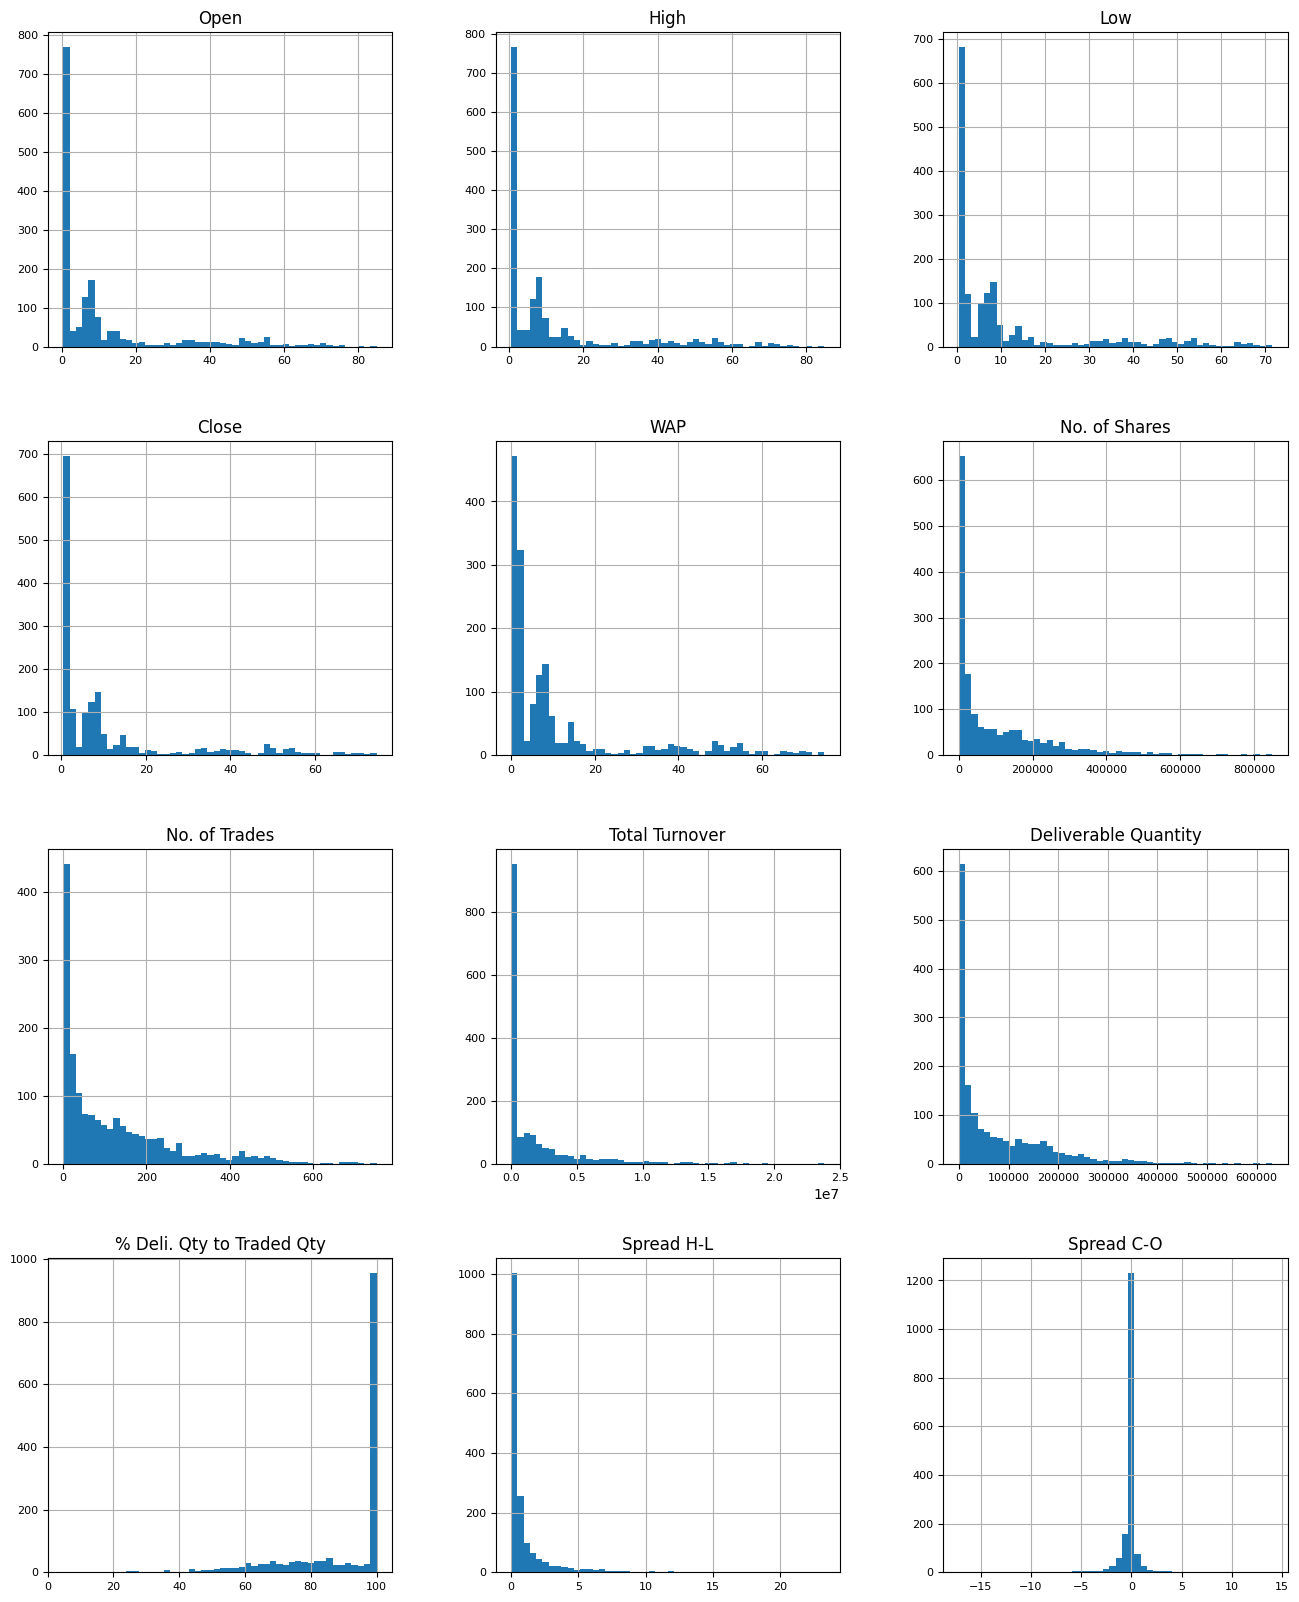

In [7]:
# 1.6 Dibujamos los histogramas de las variables numéricas para conocer su distribución
data.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

[Text(0.5, 0, 'Open'),
 Text(1.5, 0, 'High'),
 Text(2.5, 0, 'Low'),
 Text(3.5, 0, 'Close'),
 Text(4.5, 0, 'WAP'),
 Text(5.5, 0, 'No. of Shares'),
 Text(6.5, 0, 'No. of Trades'),
 Text(7.5, 0, 'Total Turnover'),
 Text(8.5, 0, 'Deliverable Quantity'),
 Text(9.5, 0, '% Deli. Qty to Traded Qty'),
 Text(10.5, 0, 'Spread H-L'),
 Text(11.5, 0, 'Spread C-O')]

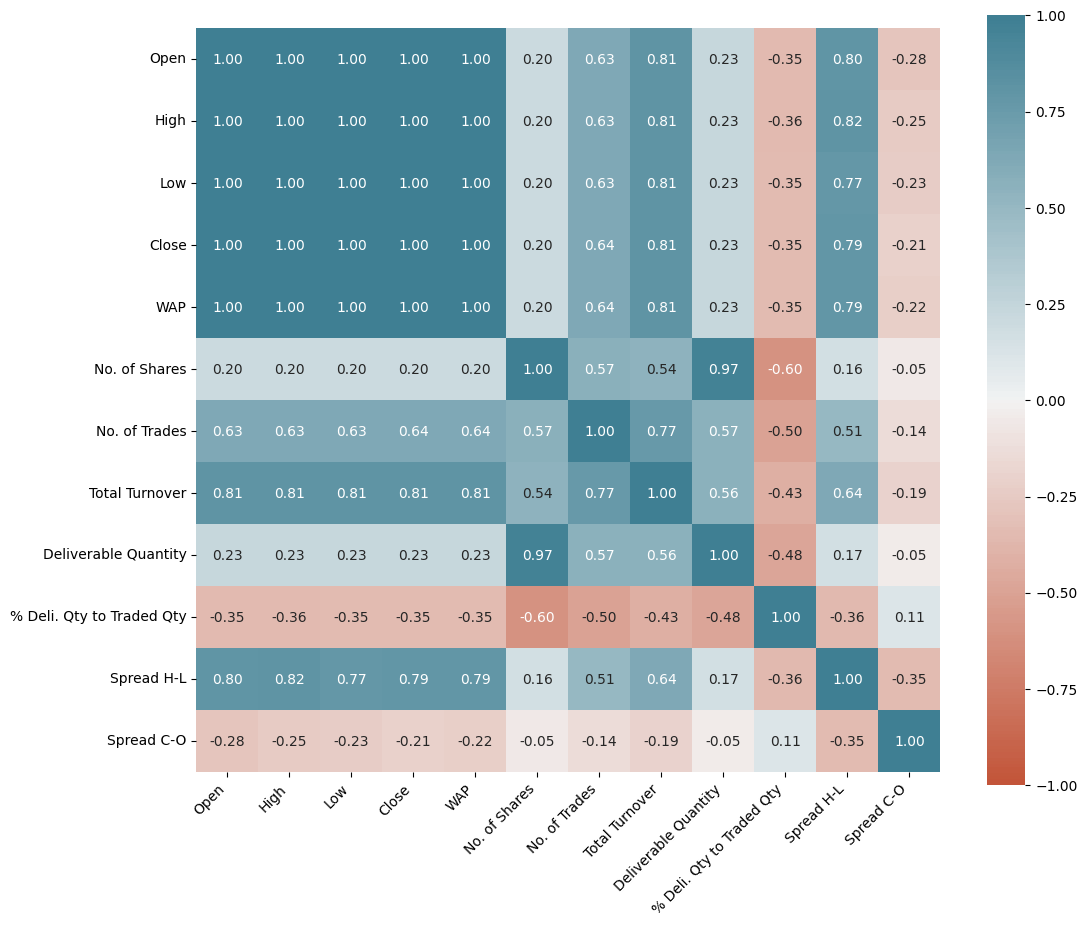

In [8]:
# Calculamos el coeficiente de correlación de Pearson
corr = data.corr(method ='pearson', numeric_only=True)

# Hacemos un headpmap con tamaño ampliado, cuadrado, divergencia con colores y con anotaciones de 2 decimales
plt.figure(figsize=(12,10))
ax = sns.heatmap(
 corr,
 vmin=-1, vmax=1, center=0,
 cmap=sns.diverging_palette(20, 220, n=200),
 square=True, annot=True, fmt=".2f"
)
# Rotamos las etiquetas del eje horizontal
ax.set_xticklabels(
 ax.get_xticklabels(),
 rotation=45,
 horizontalalignment='right'
)

### Paso 3: Realizamos el preprocesamiento de los datos

Muestro objetivo es predecir si el precio al final del día cerrará en positivo(precio final mayor del precio inicial) o no ( precio final igual o menor que el precio inicial). Por eso crearemos una nueva variable (columna) llamada **Result** calculada. Esta variable será categórica y adoptará dos valores: 0, 1. Será nuestra variable objetivo.



In [9]:
# Creamos la nueva columna que será objetivo a partir de Spread C-O: si el precio cerró en positivo será 1, si el precio cerró en 0 o en negativo será 0
data['Result'] = np.where(data['Spread C-O'] > 0, 1, 0)
data.head(10)

,Date,Open,High,Low,Close,WAP,No. of Shares,No. of Trades,Total Turnover,Deliverable Quantity,% Deli. Qty to Traded Qty,Spread H-L,Spread C-O,Result
0,2017-02-06,0.79,0.79,0.76,0.76,0.79,7430.0,7.0,5848.0,7430.0,100.0,0.03,-0.03,0
1,2017-02-03,0.79,0.79,0.79,0.79,0.79,310.0,4.0,244.0,310.0,100.0,0.00,0.00,0
2,2017-02-02,0.83,0.83,0.83,0.83,0.83,75.0,1.0,62.0,75.0,100.0,0.00,0.00,0
3,2017-01-31,0.87,0.87,0.87,0.87,0.87,1050.0,2.0,913.0,1050.0,100.0,0.00,0.00,0
4,2017-01-25,0.91,0.91,0.91,0.91,0.91,400.0,1.0,364.0,400.0,100.0,0.00,0.00,0
5,2017-01-24,0.91,0.91,0.90,0.91,0.91,3632.0,6.0,3303.0,3632.0,100.0,0.01,0.00,0
6,2017-01-23,0.91,0.91,0.91,0.91,0.91,55.0,1.0,50.0,55.0,100.0,0.00,0.00,0
7,2017-01-20,0.93,0.93,0.92,0.92,0.92,74.0,2.0,68.0,74.0,100.0,0.01,-0.01,0
8,2017-01-19,0.89,0.89,0.89,0.89,0.88,77.0,2.0,68.0,77.0,100.0,0.00,0.00,0
9,2017-01-18,0.88,0.88,0.85,0.85,0.87,84.0,2.0,73.0,84.0,100.0,0.03,-0.03,0


In [10]:
#Eliminamos las columnas que no aportan información o la aportan redundante: Date, Close y Spread C-O
data = data.drop('Spread C-O', axis=1)
data = data.drop('Close', axis=1)
data = data.drop('Date', axis=1)
data.head(10)

,Open,High,Low,WAP,No. of Shares,No. of Trades,Total Turnover,Deliverable Quantity,% Deli. Qty to Traded Qty,Spread H-L,Result
0,0.79,0.79,0.76,0.79,7430.0,7.0,5848.0,7430.0,100.0,0.03,0
1,0.79,0.79,0.79,0.79,310.0,4.0,244.0,310.0,100.0,0.00,0
2,0.83,0.83,0.83,0.83,75.0,1.0,62.0,75.0,100.0,0.00,0
3,0.87,0.87,0.87,0.87,1050.0,2.0,913.0,1050.0,100.0,0.00,0
4,0.91,0.91,0.91,0.91,400.0,1.0,364.0,400.0,100.0,0.00,0
5,0.91,0.91,0.90,0.91,3632.0,6.0,3303.0,3632.0,100.0,0.01,0
6,0.91,0.91,0.91,0.91,55.0,1.0,50.0,55.0,100.0,0.00,0
7,0.93,0.93,0.92,0.92,74.0,2.0,68.0,74.0,100.0,0.01,0
8,0.89,0.89,0.89,0.88,77.0,2.0,68.0,77.0,100.0,0.00,0
9,0.88,0.88,0.85,0.87,84.0,2.0,73.0,84.0,100.0,0.03,0


In [11]:
#Eliminamos las columnas High, Low y WAP dado que la correlación entre estas y OPEN es elevada.
data = data.drop('High', axis=1)
data = data.drop('Low', axis=1)
data = data.drop('WAP', axis=1)
data.head(10)

,Open,No. of Shares,No. of Trades,Total Turnover,Deliverable Quantity,% Deli. Qty to Traded Qty,Spread H-L,Result
0,0.79,7430.0,7.0,5848.0,7430.0,100.0,0.03,0
1,0.79,310.0,4.0,244.0,310.0,100.0,0.00,0
2,0.83,75.0,1.0,62.0,75.0,100.0,0.00,0
3,0.87,1050.0,2.0,913.0,1050.0,100.0,0.00,0
4,0.91,400.0,1.0,364.0,400.0,100.0,0.00,0
5,0.91,3632.0,6.0,3303.0,3632.0,100.0,0.01,0
6,0.91,55.0,1.0,50.0,55.0,100.0,0.00,0
7,0.93,74.0,2.0,68.0,74.0,100.0,0.01,0
8,0.89,77.0,2.0,68.0,77.0,100.0,0.00,0
9,0.88,84.0,2.0,73.0,84.0,100.0,0.03,0


### Paso 4: Aplicamos el algoritmo de Redes Neuronales y evaluamos su rendimiento

In [12]:
#Importamos las librerías necesarias para poder aplicar la red neuronal y evaluar su rendimiento

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

In [13]:
# Separamos los datos en los conjuntos de entrenamiento y test
X, y = data.drop('Result',axis=1),data['Result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
# Escalamos los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
#Obtenemos el número de valores únicos de la variable objetivo
num_classes = len(np.unique(y))

# Diseñamos la arquitectura de la red neuronal: elegimos la función de activación relu, número de capas y número de neuronas en cada capa. Agregar más capas o más neuronas puede permitir al modelo aprender representaciones más complejas, pero también puede aumentar el riesgo de sobreajuste
model = models.Sequential([
    layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)),#### Capa de entrada con 8 neuronas y función de activación ReLu
    layers.Dense(16, activation='relu'),#### La segunda capa con 16 neuronas y función de activación ReLu
    layers.Dense(32, activation='relu'),####### la tercera capa con 32 neuronas y función de activación ReLu
    layers.Dense(num_classes, activation='softmax') ###La cuarta capa es la capa de salida y la función de activación softmax
    #layers.Dense(num_classes, activation='relu')
])

model.summary()

C:\Users\david\anaconda3\envs\LabTIA01\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 818 (3.20 KB)

 Trainable params: 818 (3.20 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compilamos el modelo y le decimos el optimizador de perdida, el error y las metricas que vamos a utilizar para evaluarlo: adam,sparse_categorical_crossentropy, acurracy
model.compile(optimizer='adam', #Algunas opciones: adam, sgd, rmsprop
              loss='sparse_categorical_crossentropy', #Algunas opciones: categorical_crossentropy, sparse_categorical_crossentropy
              metrics=['accuracy']) #Algunas opciones: accurancy, recall

In [1]:
# Entrenamos el modelo: Elegimos el número de epochs. Este número determinacuántas veces el modelo verá todo el conjunto de datos de entrenamiento y test.
# El tamaño del lote (batch_size) determina cuántas muestras se utilizan para actualizar los pesos del modelo en cada paso de entrenamiento.
history = model.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.2)### Entrenas el modelo y eliges el número de ciclos que harán la la red neuronal. En este caso 150 ciclos.

NameError: name 'model' is not defined

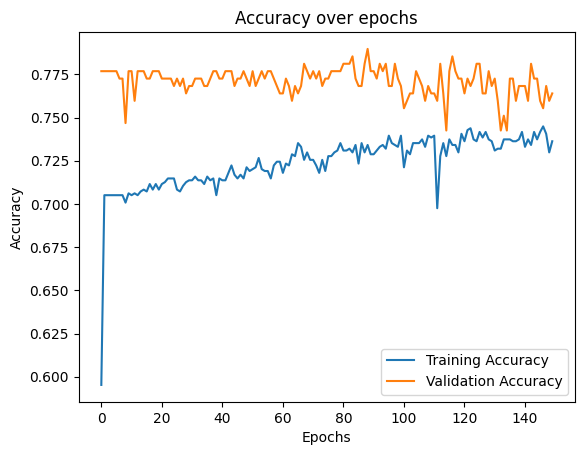

In [18]:
# Mostramos la gráfica con la evolución de la precisión (accuracy) obtenida para los datos de entrenamiento y la validación a lo largo de las épocas
plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

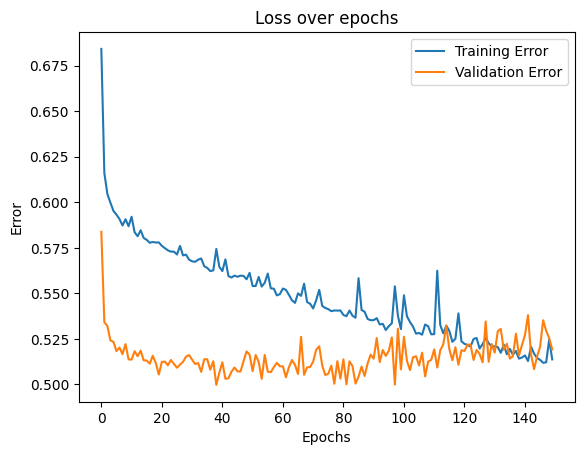

In [19]:
# Mostramos la gráfica con la evolución del error obtenido para los datos de entrenamiento y la validación a lo largo de los époch
plt.figure()
plt.plot(history.history['loss'], label='Training Error')
plt.plot(history.history['val_loss'], label='Validation Error')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()

plt.show()

In [1]:
# Realizamos la predicción con el modelo generado y los datos de Test
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

NameError: name 'model' is not defined

In [21]:
# Obtenemos la matriz de confusión de la predicción realizada
class_report = classification_report(y_test, predicted_classes)

# Mostramos la matriz de confusión
print(class_report)

              precision    recall  f1-score   support

           0       0.72      0.93      0.81       344
           1       0.53      0.18      0.26       154

    accuracy                           0.70       498
   macro avg       0.62      0.55      0.54       498
weighted avg       0.66      0.70      0.64       498



#### Paso 4.1: Aplicamos el mismo algoritmo de Redes Neuronales anterior aumentando el número de Epochs y evaluamos su rendimiento

In [22]:
# Aumentamos el número de epochs y volvemos a repetir el mismo proceso.
#Obtenemos el número de valores de la variable objetivo
num_classes = len(np.unique(y))

# Diseñamos la arquitectura de la red neuronal
model1 = models.Sequential([
    layers.Dense(8, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
    #layers.Dense(num_classes, activation='relu')
])

model1.summary()

C:\Users\david\anaconda3\envs\LabTIA01\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 8)                   │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 818 (3.20 KB)

 Trainable params: 818 (3.20 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Compilamos el modelo
model1.compile(optimizer='adam', #Algunas opciones: adam, sgd, rmsprop
              loss='sparse_categorical_crossentropy', #Algunas opciones: categorical_crossentropy, sparse_categorical_crossentropy
              metrics=['accuracy']) #Algunas opciones: accurancy, recall

In [24]:
# Entrenamos el modelo
history = model1.fit(X_train, y_train, epochs=500, batch_size=32, validation_split=0.2)

Epoch 1/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6233 - loss: 0.6714 - val_accuracy: 0.7768 - val_loss: 0.5970
Epoch 2/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7072 - loss: 0.6239 - val_accuracy: 0.7768 - val_loss: 0.5596
Epoch 3/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7094 - loss: 0.6065 - val_accuracy: 0.7768 - val_loss: 0.5423
Epoch 4/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7115 - loss: 0.6016 - val_accuracy: 0.7768 - val_loss: 0.5380
Epoch 5/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7051 - loss: 0.6002 - val_accuracy: 0.7768 - val_loss: 0.5298
Epoch 6/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7061 - loss: 0.5948 - val_accuracy: 0.7768 - val_loss: 0.5301
Epoch 7/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7061 - loss: 0.5933 - val_accuracy: 0.7768 - val_loss: 0.5312
Epoch 8/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7115 - loss: 0.5920 - val_accuracy: 0.7768 - v

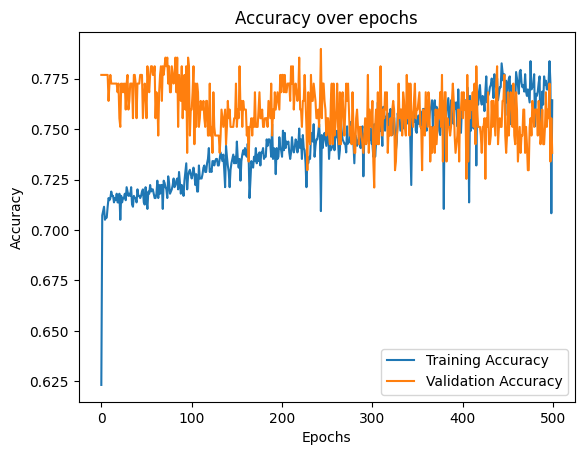

In [25]:
# Mostramos la gráfica con la evolución de la precisión (accurancy) obtenida para los datos de entrenamiento y la validación a lo largo de los epoch
plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

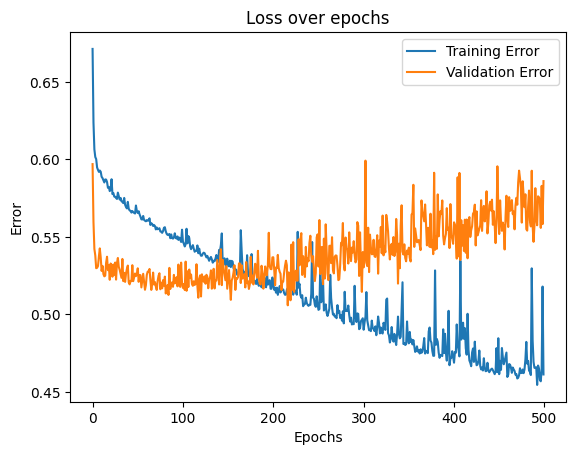

In [26]:
# Mostramos la gráfica con la evolución del error obtenido para los datos de entrenamiento y la validación a lo largo de las épocas
plt.figure()
plt.plot(history.history['loss'], label='Training Error')
plt.plot(history.history['val_loss'], label='Validation Error')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()

plt.show()

In [27]:
# Realizamos la predicción con el modelo generado y los datos de Test
predictions = model1.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [28]:
# Obtenemos la matriz de confusión de la predicción realizada
class_report = classification_report(y_test, predicted_classes)

# Mostramos la matriz de confusión
print(class_report)

              precision    recall  f1-score   support

           0       0.73      0.84      0.78       344
           1       0.46      0.30      0.36       154

    accuracy                           0.67       498
   macro avg       0.59      0.57      0.57       498
weighted avg       0.65      0.67      0.65       498



In [29]:
#Aumentamos el número de capas y neuronas.
#Obtenemos el número de valores de la variable objetivo
num_classes = len(np.unique(y))

# Diseñamos una nueva arquitectura
model2 = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
    #layers.Dense(num_classes, activation='relu')
])

model2.summary()

C:\Users\david\anaconda3\envs\LabTIA01\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 64)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,890 (148.01 KB)

 Trainable params: 37,890 (148.01 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Compilamos el modelo
model2.compile(optimizer='adam', #Algunas opciones: adam, sgd, rmsprop
              loss='sparse_categorical_crossentropy', #Algunas opciones: categorical_crossentropy, sparse_categorical_crossentropy
              metrics=['accuracy']) #Algunas opciones: accurancy, recall

In [ ]:
# Entrenamos el modelo
history = model2.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2)

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6900 - loss: 0.6227 - val_accuracy: 0.7768 - val_loss: 0.5133
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7051 - loss: 0.5959 - val_accuracy: 0.7768 - val_loss: 0.5108
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7051 - loss: 0.5991 - val_accuracy: 0.7768 - val_loss: 0.5092
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7029 - loss: 0.5895 - val_accuracy: 0.7854 - val_loss: 0.5167
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7104 - loss: 0.5836 - val_accuracy: 0.7725 - val_loss: 0.5102
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7094 - loss: 0.5846 - val_accuracy: 0.7811 - val_loss: 0.5019
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7051 - loss: 0.5829 - val_accuracy: 0.7768 - val_loss: 0.5049
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7147 - loss: 0.5760 - val_accuracy: 0.7768 - v

In [ ]:
# Mostramos la gráfica con la evolución de la precisión (accurancy) obtenida para los datos de entrenamiento y la validación a lo largo de las épocas
plt.figure()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [ ]:
# Mostramos la gráfica con la evolución del error obtenido para los datos de entrenamiento y la validación a lo largo de las épocas
plt.figure()
plt.plot(history.history['loss'], label='Training Error')
plt.plot(history.history['val_loss'], label='Validation Error')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.legend()

plt.show()

 Vemos cómo los resultados obtenidos con los datos de entrenamiento son bastante buenos, mejores que los que obteníamos con menos neuronas. Sin embargo los resultados con los datos de validación son claramente peores. Seguramente debido a un sobreajuste en el entrenamiento, que se ajusta demasiado bien a los datos de entrenamiento pero que generaliza mal.

In [ ]:
# Realizamos la predicción con el modelo generado y los datos de Test
predictions = model2.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

In [ ]:
# Obtenemos la matriz de confusión de la predicción realizada
class_report = classification_report(y_test, predicted_classes)

# Mostramos la matriz de confusión
print(class_report)

# Modificad hiperparámetros: cambiar número de epoch.... ¿mejoraría el modelo si utilizamos early stopping?
El early stopping (parada temprana) es una técnica de regularización en aprendizaje automático que detiene el entrenamiento de un modelo cuando su rendimiento en el conjunto de validación deja de mejorar, evitando el sobreajuste (overfitting).